Datasets loaded successfully!
Total rows after merging and cleaning: 327


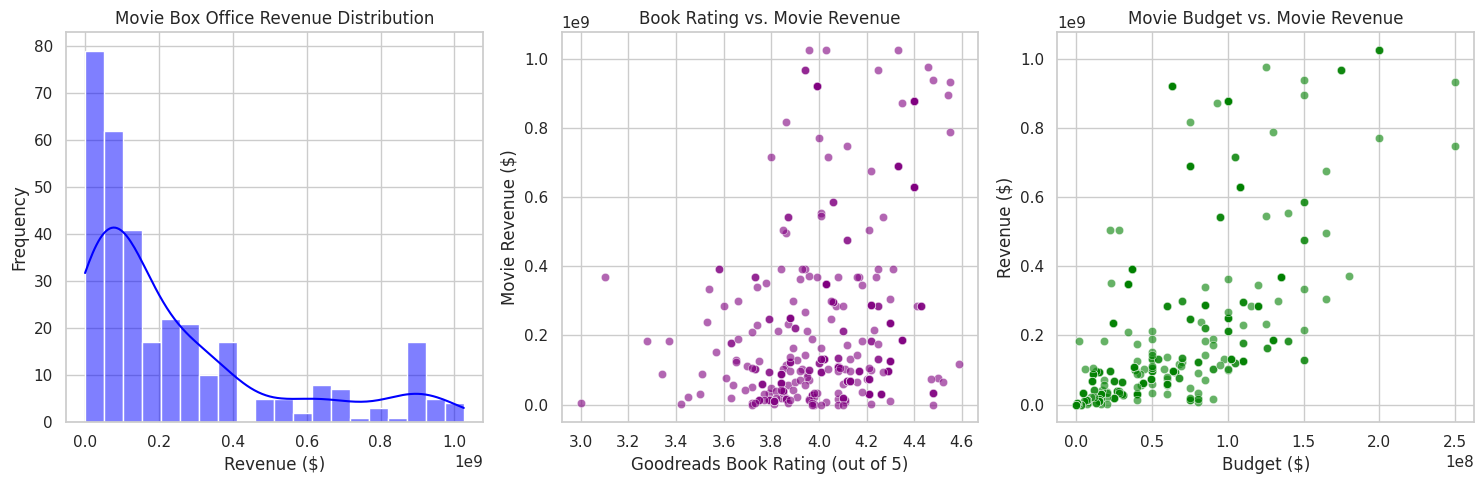


--- HYPOTHESIS TESTING ---
Number of High-Rated Book Adaptations: 178
Number of Low-Rated Book Adaptations: 149
T-Statistic: 3.9139
P-Value: 0.0001
Conclusion: The box office revenue of film adaptations of high-rated books is statistically significantly DIFFERENT from low-rated ones.

--- MACHINE LEARNING ---
Linear Regression R-squared Score: 0.4771
Random Forest Regressor R-squared Score: 0.9273


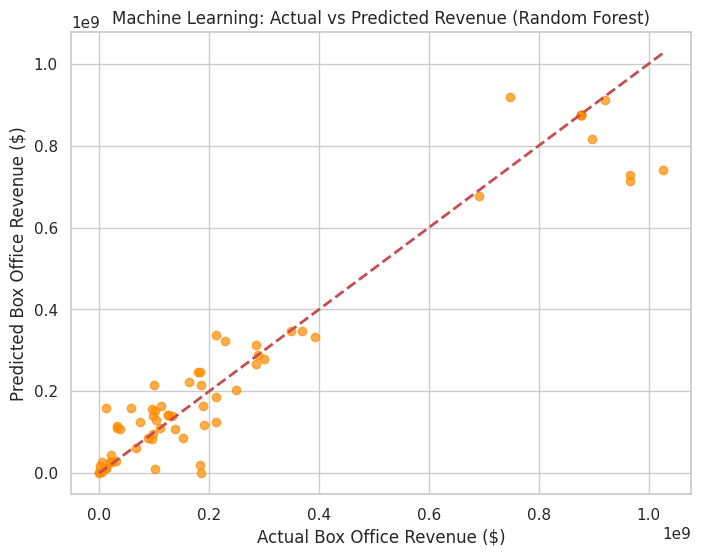

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
# --- YENİ EKLENEN ML KÜTÜPHANELERİ ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

warnings.filterwarnings('ignore')


# 1. DATA COLLECTION & PREPARATION

try:
    movies_df = pd.read_csv('tmdb_5000_movies.csv')
    books_df = pd.read_csv('books.csv')
    print("Datasets loaded successfully!")
except FileNotFoundError:
    print("ERROR: Please make sure the csv files are in the same directory as the code.")

# Filter for Science Fiction and Fantasy movies
sf_fantasy_movies = movies_df[movies_df['genres'].str.contains('Science Fiction|Fantasy', na=False)]

# Handling title mismatches (Mapping)
title_mapping = {
    "The Lord of the Rings: The Fellowship of the Ring": "The Fellowship of the Ring",
    "Harry Potter and the Philosopher's Stone": "Harry Potter and the Sorcerer's Stone"
}
sf_fantasy_movies['mapped_title'] = sf_fantasy_movies['title'].replace(title_mapping)

# Merge the two datasets
merged_df = pd.merge(sf_fantasy_movies, books_df, left_on='mapped_title', right_on='book_title', how='inner')

# Clean unnecessary or missing (NaN) data
merged_df = merged_df.dropna(subset=['revenue', 'budget', 'book_rating'])
merged_df = merged_df[merged_df['revenue'] > 0]
merged_df = merged_df[merged_df['budget'] > 0]
print(f"Total rows after merging and cleaning: {len(merged_df)}")


# 2. EXPLORATORY DATA ANALYSIS (EDA)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(merged_df['revenue'], bins=20, kde=True, color='blue')
plt.title('Movie Box Office Revenue Distribution')
plt.xlabel('Revenue ($)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.scatterplot(data=merged_df, x='book_rating', y='revenue', alpha=0.6, color='purple')
plt.title('Book Rating vs. Movie Revenue')
plt.xlabel('Goodreads Book Rating (out of 5)')
plt.ylabel('Movie Revenue ($)')

plt.subplot(1, 3, 3)
sns.scatterplot(data=merged_df, x='budget', y='revenue', alpha=0.6, color='green')
plt.title('Movie Budget vs. Movie Revenue')
plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')

plt.tight_layout()
plt.show()


# 3. HYPOTHESIS TESTING

print("\n--- HYPOTHESIS TESTING ---")
high_rated_books = merged_df[merged_df['book_rating'] >= 4.0]['revenue']
low_rated_books = merged_df[merged_df['book_rating'] < 4.0]['revenue']

print(f"Number of High-Rated Book Adaptations: {len(high_rated_books)}")
print(f"Number of Low-Rated Book Adaptations: {len(low_rated_books)}")

t_stat, p_value = stats.ttest_ind(high_rated_books, low_rated_books, equal_var=False)
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Conclusion: The box office revenue of film adaptations of high-rated books is statistically significantly DIFFERENT from low-rated ones.")
else:
    print("Conclusion: A high book rating DOES NOT make a statistically significant difference in the movie's box office revenue.")


# 4. MACHINE LEARNING: PREDICTING MOVIE REVENUE

print("\n--- MACHINE LEARNING ---")

# Define Features (X) and Target (y)
# We want to predict Revenue based on Budget and Book Rating
features = ['budget', 'book_rating']
X = merged_df[features]
y = merged_df['revenue']

# Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Model 1: Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_r2 = r2_score(y_test, lr_predictions)
print(f"Linear Regression R-squared Score: {lr_r2:.4f}")

# --- Model 2: Random Forest Regressor ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_predictions)
print(f"Random Forest Regressor R-squared Score: {rf_r2:.4f}")

# Plotting the prediction accuracy of the Random Forest model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_predictions, alpha=0.7, color='darkorange')
# Plotting the ideal prediction line (Actual = Predicted)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Machine Learning: Actual vs Predicted Revenue (Random Forest)')
plt.xlabel('Actual Box Office Revenue ($)')
plt.ylabel('Predicted Box Office Revenue ($)')
plt.grid(True)
plt.show()